#📌 Extracción

In [92]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [93]:
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

df_final = pd.concat([
    df[['customerID','Churn']],
    df_customer,
    df_phone,
    df_internet,
    df_account
], axis=1)

df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [94]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [95]:
df_final.duplicated().sum()
df_final['customerID'].duplicated().sum()

0

In [96]:
df_final.isnull().sum() 

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64

In [97]:

# eliminando las filas con valores "" en la columna 'Churn'
df_final = df_final[df_final['Churn'] != ""]

In [98]:
print(df_final['Charges.Total'].dtype)
# convirtiendo a float
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')

object


In [99]:
for col in df_final.select_dtypes(include='object').columns:
    df_final[col] = df_final[col].str.lower().str.strip()

In [100]:
df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-orfbo,no,female,0,yes,yes,9,yes,no,dsl,...,yes,no,yes,yes,no,one year,yes,mailed check,65.6,593.30
1,0003-mknfe,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,no,yes,month-to-month,no,mailed check,59.9,542.40
2,0004-tlhlj,yes,male,0,no,no,4,yes,no,fiber optic,...,no,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85
3,0011-igkff,yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85
4,0013-exchz,yes,female,1,yes,no,3,yes,no,fiber optic,...,no,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.40


In [101]:
import numpy as np
df_final["cuenta_diaria"]= df_final["Charges.Monthly"] / df_final["tenure"].replace(0, np.nan)


In [102]:
df_final.describe()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,cuenta_diaria
count,7043.000000,7043.000000,7043.000000,7032.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441,8.620087
std,0.368612,24.559481,30.090047,2266.771362,16.352057
min,0.000000,0.000000,18.250000,18.800000,0.268056
25%,0.000000,9.000000,35.500000,401.450000,1.277708
50%,0.000000,29.000000,70.350000,1397.475000,2.147286
75%,0.000000,55.000000,89.850000,3794.737500,6.611218
max,1.000000,72.000000,118.750000,8684.800000,102.450000


Gráfico que muestra la cantidad de personas que abandonan y las que no.

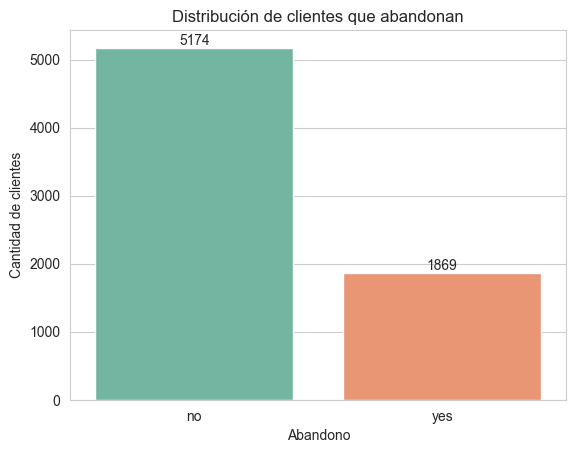

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(x='Churn', data=df_final, hue='Churn')

plt.title("Distribución de clientes que abandonan")
plt.xlabel("Abandono")
plt.ylabel("Cantidad de clientes")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

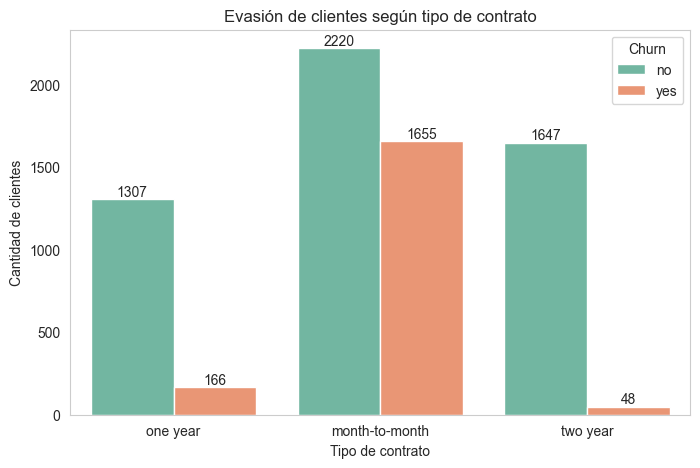

In [104]:

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")
sns.set_palette("Set2")
ax = sns.countplot(data=df_final, x="Contract", hue="Churn")

plt.title("Evasión de clientes según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")
plt.grid(axis='y')
for container in ax.containers:
    ax.bar_label(container)

plt.show()

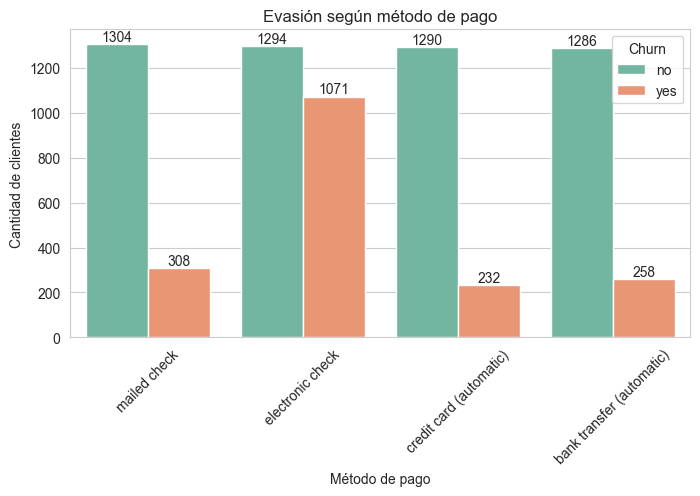

In [113]:
plt.figure(figsize=(8,4))
ax = sns.countplot(x="PaymentMethod", hue="Churn", data=df_final)

plt.title("Evasión según método de pago")
plt.xticks(rotation=45)
plt.ylabel("Cantidad de clientes")
plt.xlabel("Método de pago")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

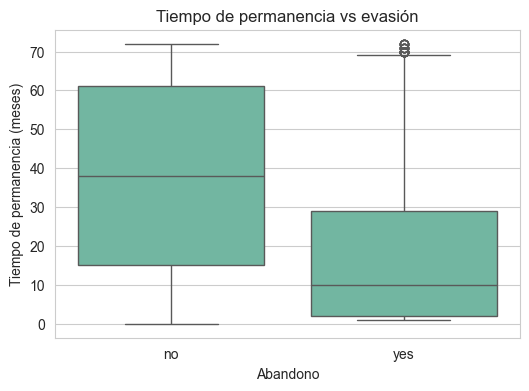

In [106]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="tenure", data=df_final)

plt.title("Tiempo de permanencia vs evasión")
plt.ylabel("Tiempo de permanencia (meses)")
plt.xlabel("Abandono")
plt.show()

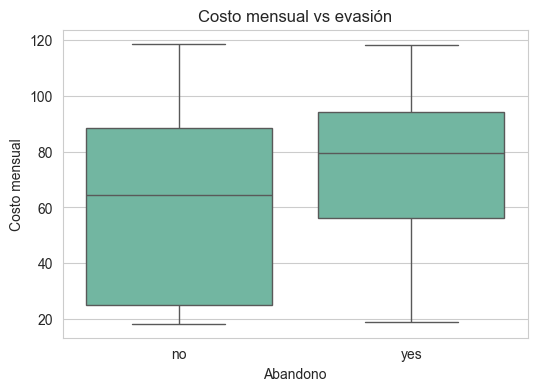

In [107]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="Charges.Monthly", data=df_final)

plt.title("Costo mensual vs evasión")
plt.ylabel("Costo mensual")
plt.xlabel("Abandono")  
plt.show()

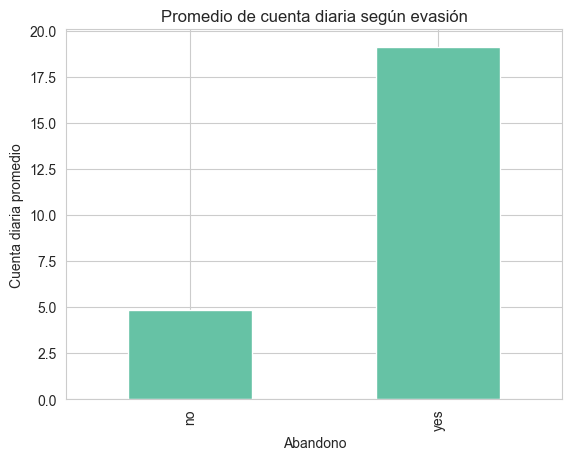

In [108]:


df_final.groupby("Churn")["cuenta_diaria"].mean().plot(kind="bar")

plt.title("Promedio de cuenta diaria según evasión")
plt.ylabel("Cuenta diaria promedio")
plt.xlabel("Abandono")   
plt.show()

Luego de realizar el análisis exploratorio de los datos, se identificaron algunos patrones relacionados con el abandono del servicio por parte de los clientes.

Se observa que aproximadamente el 26 % de los clientes han cancelado el servicio, mientras que la mayoría permanece activa, este porcentaje indica que existe un nivel considerable de evasión que podría impactar en la retención de clientes.

Uno de los factores más asociados al abandono es el tipo de contrato. Los clientes con contratos mensuales (mes a mes) presentan una mayor tendencia a cancelar el servicio en comparación con aquellos con contratos de mayor duración.

También, el método de pago muestra una tendencia relevante, ya que los clientes que utilizan cheque electrónico presentan mayores niveles de evasión según los gráficos analizados.

Por otro lado, el tiempo de permanencia en la empresa también influye en el abandono. Se observa que muchos clientes cancelan el servicio durante los primeros meses de contratación, lo que sugiere que este período es clave para la fidelización.

Finalmente, se identifica una relación entre los costos del servicio y la evasión, donde los clientes con cargos mensuales y costos diarios más altos presentan una mayor tendencia a abandonar el servicio.

En general, los resultados sugieren que factores como contratos de corta duración, menor permanencia y costos más elevados están relacionados con una mayor probabilidad de cancelación del servicio.
